In [1]:

!pip install pandas numpy scikit-learn

import os
import re
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries installed successfully!")

Libraries installed successfully!


In [5]:
!pip install matplotlib

In [7]:
import sys

print(sys.executable)

C:\Users\acer\anaconda3\envs\pytorch_env\python.exe


In [8]:
import sys
!{sys.executable} -m pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 1.4 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.3 MB 1.3 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.3 MB 1.5 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.3 MB 1.6 MB/s eta 0:00:05
   ---------- ----------------------------- 2.4/9.3 MB 1.7 MB/s eta 0:00:05
   ------------- -------------------------- 3.1/9.3 MB 1.9 MB/s eta 0:00:04
   --------------- ------------------------ 3.7/9.3 MB 2.0 MB/s eta 0:00:03
   -------------------- ------------------- 4.7/9.3 MB 2.3 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.3 MB 2.5 MB/s eta 0:00:02
   ---------------------------- ----------- 6.6/9.3 MB 2.7 MB/s eta 0:00:02
   ------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import matplotlib.pyplot as plt

print("Matplotlib is working!")

Matplotlib is building the font cache; this may take a moment.


Matplotlib is working!


In [3]:
# ============================================================
#       SIMILARITY / PLAGIARISM DETECTOR
# ============================================================

import os
import re
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# 1. FIND THE ASSIGNMENT FILES
# ============================================================

# Search for all .txt files in the current folder
txt_files = []

for root, folders, files in os.walk("."):

    for file in files:

        if file.lower().endswith(".txt"):

            # Ignore unnecessary text files
            if "Assignment_" in file:

                file_path = os.path.join(root, file)

                txt_files.append(file_path)


# Remove duplicate paths
txt_files = list(set(txt_files))


print("=" * 60)
print("SIMILARITY / PLAGIARISM DETECTOR")
print("=" * 60)

print("\nAssignment files found:", len(txt_files))

for file in txt_files:
    print("-", os.path.basename(file))


# ============================================================
# 2. CHECK FILES
# ============================================================

if len(txt_files) < 2:

    print("\nERROR!")
    print("At least 2 assignment files are required.")

else:

    # ========================================================
    # 3. LOAD ASSIGNMENTS
    # ========================================================

    documents = {}

    for file_path in txt_files:

        file_name = os.path.basename(file_path)

        with open(
            file_path,
            "r",
            encoding="utf-8",
            errors="ignore"
        ) as file:

            documents[file_name] = file.read()


    print("\nAll assignments loaded successfully!")


    # ========================================================
    # 4. CLEAN AND NORMALIZE TEXT
    # ========================================================

    def clean_text(text):

        # Convert to lowercase
        text = text.lower()

        # Remove special characters
        text = re.sub(
            r"[^a-z0-9\s]",
            " ",
            text
        )

        # Remove extra spaces
        text = re.sub(
            r"\s+",
            " ",
            text
        )

        return text.strip()


    document_names = list(documents.keys())

    cleaned_documents = []

    for name in document_names:

        cleaned = clean_text(
            documents[name]
        )

        cleaned_documents.append(cleaned)


    print("Text cleaning completed!")


    # ========================================================
    # 5. TF-IDF VECTORIZATION
    # ========================================================

    vectorizer = TfidfVectorizer(
        stop_words="english"
    )

    tfidf_matrix = vectorizer.fit_transform(
        cleaned_documents
    )

    print("TF-IDF vectorization completed!")

    print(
        "TF-IDF matrix shape:",
        tfidf_matrix.shape
    )


    # ========================================================
    # 6. COSINE SIMILARITY
    # ========================================================

    similarity_matrix = cosine_similarity(
        tfidf_matrix
    )

    similarity_percentage = (
        similarity_matrix * 100
    )


    # ========================================================
    # 7. DISPLAY SIMILARITY MATRIX
    # ========================================================

    similarity_df = pd.DataFrame(
        similarity_percentage,
        index=document_names,
        columns=document_names
    )

    print("\n" + "=" * 60)
    print("SIMILARITY MATRIX (%)")
    print("=" * 60)

    print(
        similarity_df.round(2)
    )


    # ========================================================
    # 8. PLAGIARISM THRESHOLD
    # ========================================================

    threshold = 70

    print(
        "\nPlagiarism threshold:",
        str(threshold) + "%"
    )


    # ========================================================
    # 9. COMPARE DOCUMENT PAIRS
    # ========================================================

    results = []

    for i in range(
        len(document_names)
    ):

        for j in range(
            i + 1,
            len(document_names)
        ):

            document1 = document_names[i]

            document2 = document_names[j]

            score = similarity_percentage[
                i, j
            ]


            # Determine status
            if score >= threshold:

                status = "Possible Plagiarism"

            else:

                status = "Low Similarity"


            results.append({

                "Document 1": document1,

                "Document 2": document2,

                "Similarity (%)": round(
                    score,
                    2
                ),

                "Status": status
            })


    # ========================================================
    # 10. CREATE RANKED REPORT
    # ========================================================

    report = pd.DataFrame(
        results
    )

    report = report.sort_values(
        by="Similarity (%)",
        ascending=False
    )

    report = report.reset_index(
        drop=True
    )

    report.index += 1


    # ========================================================
    # 11. DISPLAY RANKED REPORT
    # ========================================================

    print("\n" + "=" * 60)
    print("RANKED SIMILARITY REPORT")
    print("=" * 60)

    print(
        report.to_string()
    )


    # ========================================================
    # 12. DISPLAY SUSPICIOUS PAIRS
    # ========================================================

    suspicious = report[
        report["Similarity (%)"] >= threshold
    ]


    print("\n" + "=" * 60)
    print("SUSPICIOUS DOCUMENT PAIRS")
    print("=" * 60)


    if len(suspicious) > 0:

        for _, row in suspicious.iterrows():

            print(
                "\nDocument 1:",
                row["Document 1"]
            )

            print(
                "Document 2:",
                row["Document 2"]
            )

            print(
                "Similarity:",
                str(
                    row["Similarity (%)"]
                ) + "%"
            )

            print(
                "Status:",
                row["Status"]
            )

            print("-" * 50)


    else:

        print(
            "No document pairs crossed the",
            str(threshold) + "% threshold."
        )


    # ========================================================
    # 13. SAVE REPORT AS CSV
    # ========================================================

    report.to_csv(
        "plagiarism_similarity_report.csv",
        index=False
    )

    print("\n" + "=" * 60)
    print("REPORT SAVED SUCCESSFULLY")
    print("=" * 60)

    print(
        "File: plagiarism_similarity_report.csv"
    )


    # ========================================================
    # 14. FINAL SUMMARY
    # ========================================================

    print("\n" + "=" * 60)
    print("PROJECT SUMMARY")
    print("=" * 60)

    print(
        "Documents analyzed:",
        len(documents)
    )

    print(
        "Document pairs compared:",
        len(report)
    )

    print(
        "Suspicious pairs:",
        len(suspicious)
    )

    print(
        "Similarity threshold:",
        str(threshold) + "%"
    )

    print("\nPlagiarism detection completed!")

SIMILARITY / PLAGIARISM DETECTOR

Assignment files found: 6
- Assignment_B.txt
- Assignment_A.txt
- Assignment_D.txt
- Assignment_F.txt
- Assignment_E.txt
- Assignment_C.txt

All assignments loaded successfully!
Text cleaning completed!
TF-IDF vectorization completed!
TF-IDF matrix shape: (6, 102)

SIMILARITY MATRIX (%)
                  Assignment_B.txt  Assignment_A.txt  Assignment_D.txt  \
Assignment_B.txt            100.00             77.29               0.0   
Assignment_A.txt             77.29            100.00               0.0   
Assignment_D.txt              0.00              0.00             100.0   
Assignment_F.txt             13.91             15.76               0.0   
Assignment_E.txt              6.73              8.88               0.0   
Assignment_C.txt             13.29             21.30               0.0   

                  Assignment_F.txt  Assignment_E.txt  Assignment_C.txt  
Assignment_B.txt             13.91              6.73             13.29  
Assignment_A.

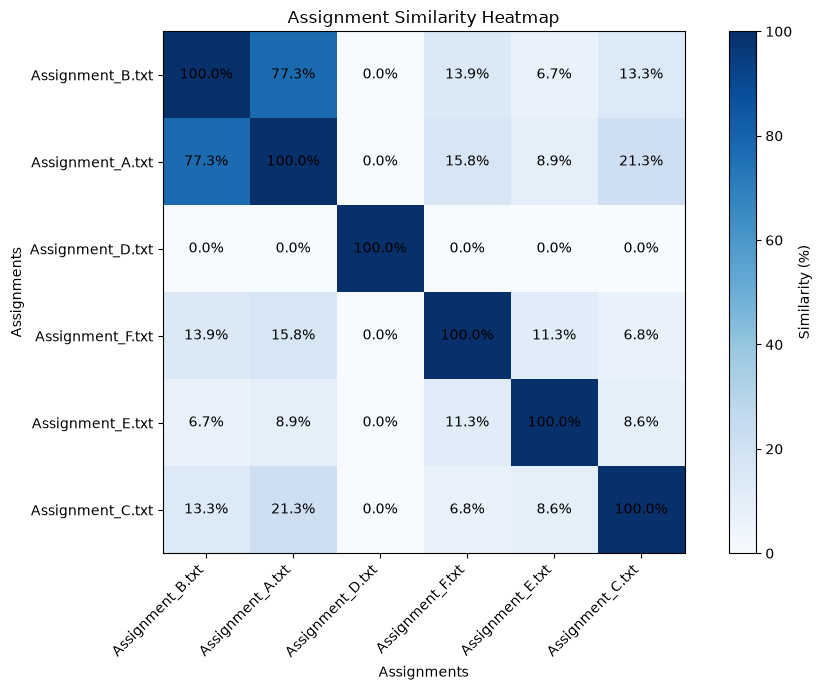

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.imshow(
    similarity_df,
    cmap="Blues",
    interpolation="nearest"
)

plt.colorbar(label="Similarity (%)")

plt.xticks(
    range(len(similarity_df.columns)),
    similarity_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(similarity_df.index)),
    similarity_df.index
)

for i in range(len(similarity_df.index)):
    for j in range(len(similarity_df.columns)):
        value = similarity_df.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )

plt.title("Assignment Similarity Heatmap")
plt.xlabel("Assignments")
plt.ylabel("Assignments")

plt.tight_layout()
plt.show()